# PharmIQ — Model Training & Selection
Pipeline construction, cross-validation, hyperparameter analysis, and final model selection.

In [1]:
import os, sys
os.chdir('../..')
sys.path.insert(0, os.getcwd())

import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from src.data.ingest import load_raw, clean
from src.features.engineer import engineer, FEATURE_COLS, TARGET_COL

df = engineer(clean(load_raw('data/raw/tata_1mg_Medicine_data.csv')))
X = df[FEATURE_COLS]
y = df[TARGET_COL]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Train: {X_train.shape} | Test: {X_test.shape}')

Train: (218924, 8) | Test: (54731, 8)


## 1. Load Trained Pipeline

In [2]:
pipeline = joblib.load('models/price_tier_classifier_v1.pkl')
print('Pipeline steps:')
for name, step in pipeline.steps:
    print(f'  {name}: {type(step).__name__}')

Pipeline steps:
  preprocessor: ColumnTransformer
  classifier: XGBClassifier


## 2. Training Metrics

In [3]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)

print(f'Test Accuracy : {accuracy_score(y_test, y_pred):.4f}')
print(f'AUC OvR Macro : {roc_auc_score(y_test, y_proba, multi_class="ovr", average="macro"):.4f}')
print()
print(classification_report(y_test, y_pred, target_names=["Budget", "Mid", "Premium", "Luxury"]))

Test Accuracy : 0.6000
AUC OvR Macro : 0.8404

              precision    recall  f1-score   support

      Budget       0.61      0.67      0.64     13722
         Mid       0.62      0.51      0.56     13749
     Premium       0.57      0.48      0.52     13629
      Luxury       0.60      0.74      0.66     13631

    accuracy                           0.60     54731
   macro avg       0.60      0.60      0.60     54731
weighted avg       0.60      0.60      0.60     54731



## 3. Confusion Matrix

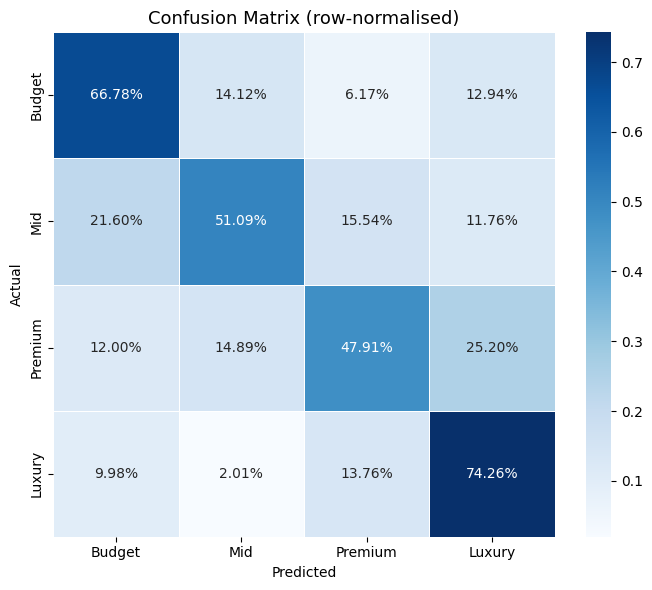

In [4]:
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
cm_pct = cm / cm.sum(axis=1, keepdims=True)
labels = ['Budget', 'Mid', 'Premium', 'Luxury']

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm_pct, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=labels, yticklabels=labels, ax=ax,
            linewidths=0.5, linecolor='white')
ax.set_title('Confusion Matrix (row-normalised)', fontsize=13)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('artifacts/confusion_matrix.png', bbox_inches='tight')
plt.show()

## 4. ROC Curves (OvR)

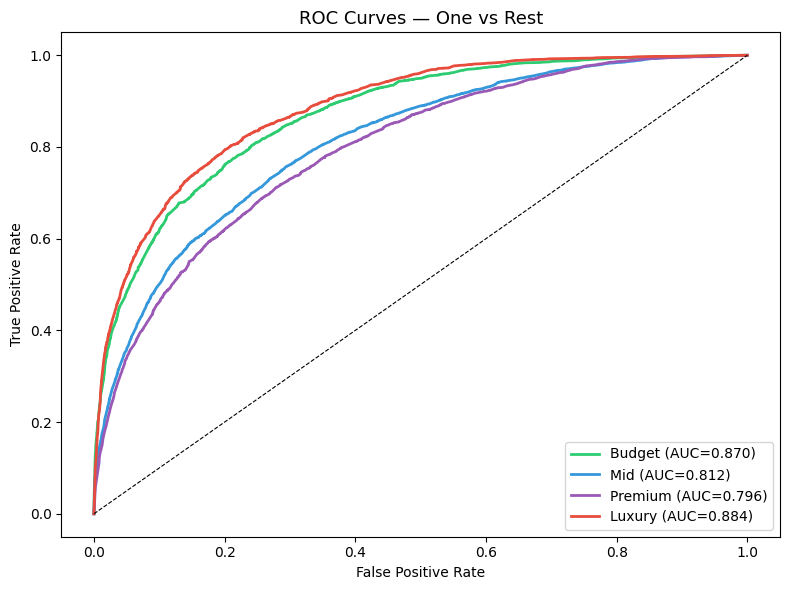

In [5]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

y_bin = label_binarize(y_test, classes=[0, 1, 2, 3])
colors = ['#2ECC71', '#3498DB', '#9B59B6', '#E74C3C']

fig, ax = plt.subplots(figsize=(8, 6))
for i, (label, color) in enumerate(zip(labels, colors)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_proba[:, i])
    auc_score = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, linewidth=2, label=f'{label} (AUC={auc_score:.3f})')

ax.plot([0,1], [0,1], 'k--', linewidth=0.8)
ax.set_title('ROC Curves — One vs Rest', fontsize=13)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('artifacts/roc_curves.png', bbox_inches='tight')
plt.show()

## 5. XGBoost Feature Importances

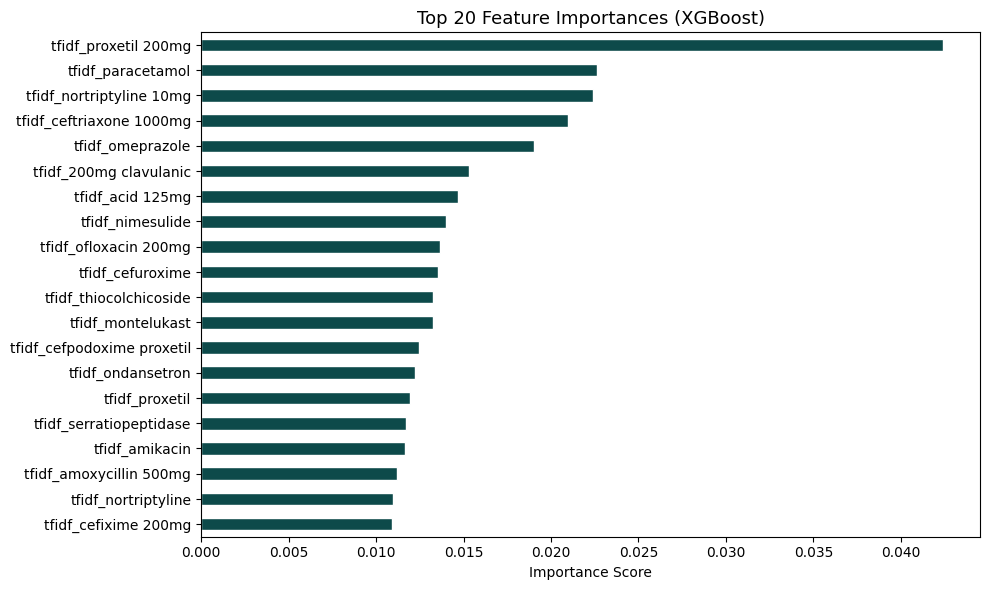

In [6]:
xgb = pipeline.named_steps['classifier']
importances = xgb.feature_importances_

# Get feature names from preprocessor
preprocessor = pipeline.named_steps['preprocessor']
num_names = ['salt_count', 'pack_size_units', 'manufacturer_tier', 'max_dose_mg', 'is_branded', 'log_max_dose']
cat_names = ['dosage_form']
tfidf_names = [f'tfidf_{t}' for t in preprocessor.named_transformers_['tfidf'].get_feature_names_out()]
all_names = num_names + cat_names + tfidf_names

# Top 20
feat_imp = pd.Series(importances, index=all_names).sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 6))
feat_imp.sort_values().plot(kind='barh', ax=ax, color='#0D4A4A', edgecolor='white')
ax.set_title('Top 20 Feature Importances (XGBoost)', fontsize=13)
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('artifacts/feature_importances.png', bbox_inches='tight')
plt.show()

In [1]:
import os, sys
os.chdir(r'c:\Users\faffo\Project\ML_PharmIQ')
sys.path.insert(0, os.getcwd())

from src.data.ingest import load_raw, clean
from src.features.engineer import engineer, FEATURE_COLS, TARGET_COL
import pandas as pd

df = engineer(clean(load_raw('data/raw/tata_1mg_Medicine_data.csv')))
print(f'Shape: {df.shape}')
print(f'FEATURE_COLS: {FEATURE_COLS}')
print(f'\nTarget distribution:')
print(df[TARGET_COL].value_counts().sort_index())
print(f'\nMax/min ratio: {df[TARGET_COL].value_counts().max() / df[TARGET_COL].value_counts().min():.4f}')

Shape: (273655, 17)
FEATURE_COLS: ['salt_count', 'pack_size_units', 'manufacturer_tier', 'dosage_form', 'max_dose_mg', 'log_max_dose', 'Salt_Composition']

Target distribution:
Price_Tier
0    68609
1    68745
2    68145
3    68156
Name: count, dtype: int64

Max/min ratio: 1.0088
